In [4]:
!pip install diffusers transformers accelerate safetensors ftfy datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00


In [5]:
!pip install git+https://github.com/huggingface/diffusers

  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-s9cqos2q
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-s9cqos2q
  Resolved https://github.com/huggingface/diffusers to commit de5fcf6fe322dde5ea119f0491dada9945f8a649
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 16.1 MB/s eta 0:00:00
  Created wheel for diffusers: filename=diffusers-0.39.0.dev0-py3-none-any.whl size=5361576 sha256=74d79e97cafb47564853a672a6e40b353e89dc7ffb5461e18a9b275ba25cec61
  Stored in directory: /tmp/pip-ephem-wheel-cache-1a9_ekib/wheels/90/d4/44/a58bc00fb405fefb633b0d9d2307f6e3aec6cc1775d82555d3
Successfully built diffusers
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled sa

In [6]:
!wget https://raw.githubusercontent.com/huggingface/diffusers/main/examples/textual_inversion/textual_inversion.py

--2026-05-15 19:35:08--  https://raw.githubusercontent.com/huggingface/diffusers/main/examples/textual_inversion/textual_inversion.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 40645 (40K) [text/plain]
Saving to: ‘textual_inversion.py’

textual_inversion.p 100%[===================>]  39.69K  --.-KB/s    in 0.003s  

2026-05-15 19:35:08 (15.1 MB/s) - ‘textual_inversion.py’ saved [40645/40645]



In [7]:
import os

dataset_path = "dataset/processed"

In [9]:
from huggingface_hub import notebook_login
notebook_login()

In [10]:
placeholder_token = "<toycar>"

In [11]:
!accelerate launch textual_inversion.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="dataset/processed" \
  --learnable_property="object" \
  --placeholder_token="<toycar>" \
  --initializer_token="toy" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --max_train_steps=1000 \
  --learning_rate=5.0e-04 \
  --output_dir="textual_inversion_output"

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
tokenizer_config.json: 100% 806/806 [00:00<00:00, 4.35MB/s]
vocab.json: 1.06MB [00:00, 12.2MB/s]
merges.txt: 525kB [00:00, 10.4MB/s]
special_tokens_map.json: 100% 472/472 [00:00<00:00, 2.96MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

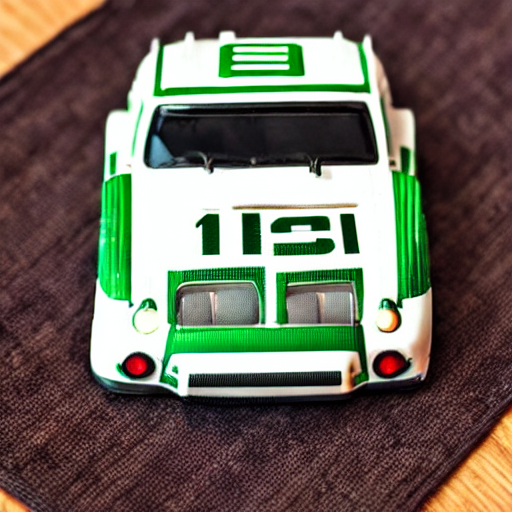

In [15]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")
pipe.load_textual_inversion("textual_inversion_output")

prompt = "a photo of <toycar> on a table"

image = pipe(prompt).images[0]
image.save("results/textual_inversion/result1.png")
image

  0%|          | 0/50 [00:00<?, ?it/s]

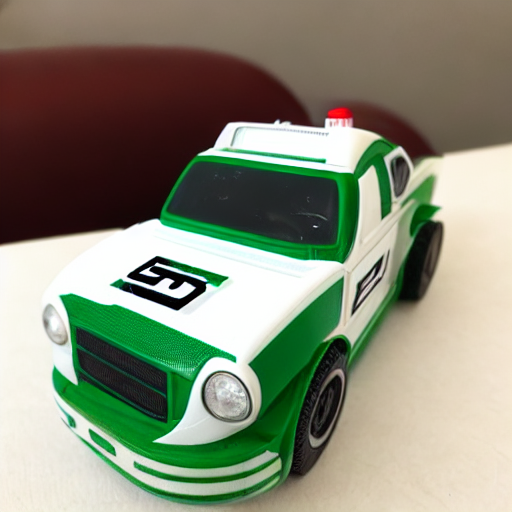

In [16]:
prompt = "a cartoon style <toycar>"

image = pipe(prompt).images[0]
image.save("results/textual_inversion/result2.png")
image

  0%|          | 0/50 [00:00<?, ?it/s]

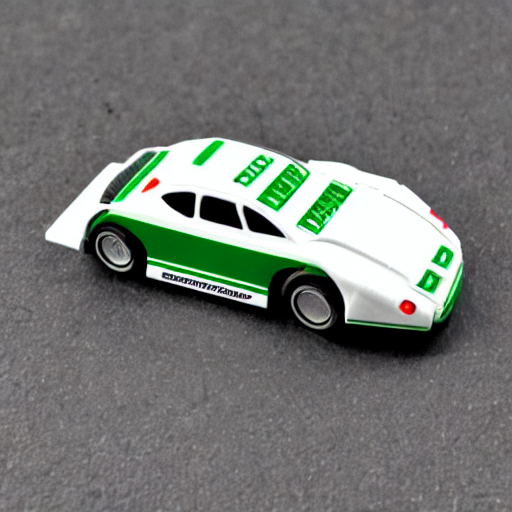

In [17]:
prompt = "a futuristic <toycar>"

image = pipe(prompt).images[0]
image.save("results/textual_inversion/result3.png")
image

  0%|          | 0/50 [00:00<?, ?it/s]

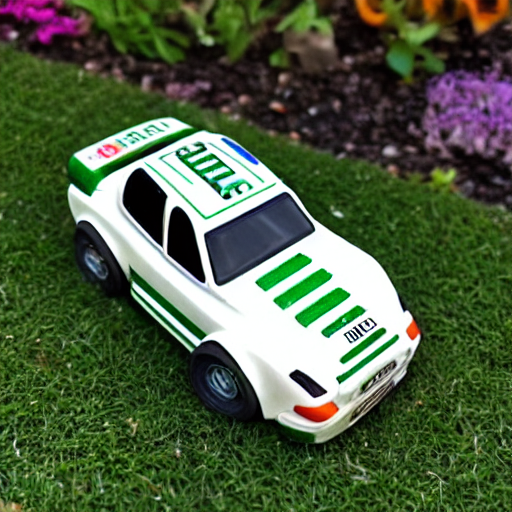

In [18]:
prompt = "a photo of <toycar> in a garden"

image = pipe(prompt).images[0]
image.save("results/textual_inversion/result4.png")
image

In [19]:
from google.colab import files

files.download("results/textual_inversion/result1.png")
files.download("results/textual_inversion/result2.png")
files.download("results/textual_inversion/result3.png")
files.download("results/textual_inversion/result4.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
files.download("textual_inversion_output/learned_embeds.safetensors")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>